# Zajęcie 2. Ćwiczenie: Klasyfikacja/Regresja na danych klinicznych oraz CNN dla obrazów

Ten notatnik **wyjaśnia i realizuje** instrukcję do ćwiczenia laboratoryjnego składającego się z dwóch tematów:

1. **Budowa prostych modeli klasyfikacji i regresji** — rozpoznawanie chorób na podstawie danych klinicznych.
2. **Implementacja sieci neuronowych (CNN)** — tworzenie i trenowanie prostej sieci konwolucyjnej do klasyfikacji obrazów (użyjemy zbioru *sklearn digits* jako *proxy* danych obrazowych medycznych do celów dydaktycznych).

> **Uwaga dot. danych obrazowych:** w warunkach bez dostępu do internetu wykorzystujemy wbudowany zbiór `sklearn.datasets.load_digits` (8×8 pikseli). W środowisku laboratoryjnym możesz zastąpić go własnym zbiorem obrazów medycznych (np. RTG) o analogicznym przepływie pracy.


## 0. Środowisko i biblioteki
Zainstaluj brakujące biblioteki we własnym środowisku (np. `pip install pandas scikit-learn tensorflow matplotlib`). Do wizualizacji używamy **matplotlib** (bez stylów i bez ustawiania kolorów ręcznie).

In [11]:

# --- Importy ---
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report,
                             mean_squared_error, r2_score)
from sklearn.datasets import load_digits

# TensorFlow/Keras (dla CNN)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (8, 5)

print("Środowisko gotowe.")

Środowisko gotowe.


## 1. Temat: Proste modele klasyfikacji i regresji (dane kliniczne)

**Cel dydaktyczny:** pokazać pełny przepływ pracy — od przygotowania danych, przez budowę modeli, po ocenę i interpretację.

**Kroki:**
1. Import danych klinicznych (CSV/Excel) lub wygenerowanie przykładowego zbioru.
2. Wstępne przetwarzanie: brakujące dane, typy, inżynieria cech (np. BMI).
3. Klasyfikacja: przewidywanie `hypertension` na podstawie cech klinicznych.
4. Regresja: przewidywanie wartości `systolic_bp` (ciśnienie skurczowe).
5. Ocena jakości i wizualizacja wyników (krzywa ROC, wykres reszt).

### 1.1 Import lub generowanie danych
Jeśli posiadasz plik `dane_pacjentow_demo.csv` (utworzony wcześniej), zostanie wczytany. W przeciwnym razie wygenerujemy przykładowe dane o podobnej strukturze.

In [12]:

CSV_PATH = "/mnt/data/dane_pacjentow_demo.csv"

def generate_demo_csv(path):
    rng = np.random.default_rng(42)
    N = 500
    age = rng.integers(18, 90, size=N)
    sex = rng.choice(["F", "M"], size=N)
    height_cm = rng.normal(170, 10, size=N).clip(140, 200)
    weight_kg = rng.normal(75, 15, size=N).clip(40, 160)
    bmi = weight_kg / (height_cm/100)**2
    systolic_bp = rng.normal(130, 20, size=N).round().clip(90, 220)
    diastolic_bp = rng.normal(80, 12, size=N).round().clip(50, 140)
    glucose = rng.normal(100, 25, size=N).round().clip(60, 300)
    visit_date = pd.to_datetime("2024-01-01") + pd.to_timedelta(rng.integers(0, 365, size=N), unit="D")
    hypertension = ((systolic_bp >= 140) | (diastolic_bp >= 90)).astype(int)
    demo = pd.DataFrame({
        "patient_id": range(1, N+1),
        "age": age,
        "sex": sex,
        "height_cm": height_cm.round(1),
        "weight_kg": weight_kg.round(1),
        "bmi": bmi.round(1),
        "systolic_bp": systolic_bp.astype(int),
        "diastolic_bp": diastolic_bp.astype(int),
        "glucose": glucose.astype(int),
        "visit_date": visit_date,
        "hypertension": hypertension
    })
    demo.to_csv(path, index=False)
    return demo

if os.path.exists(CSV_PATH):
    df = pd.read_csv(CSV_PATH)
    print("Wczytano istniejący plik:", CSV_PATH)
else:
    df = generate_demo_csv(CSV_PATH)
    print("Wygenerowano dane i zapisano do:", CSV_PATH)

display(df.head(10))
print("\nInformacje:")
df.info()
print("\nKształt:", df.shape)

Wczytano istniejący plik: /mnt/data/dane_pacjentow_demo.csv


,patient_id,age,sex,height_cm,weight_kg,bmi,systolic_bp,diastolic_bp,glucose,visit_date,hypertension
0,1,24,F,184.3,52.0,15.3,141,73,78,2024-06-27,1
1,2,73,M,170.9,78.4,26.9,132,80,105,2024-02-05,0
2,3,65,M,175.8,86.0,27.8,137,77,99,2024-10-28,0
3,4,49,M,169.4,80.6,28.1,146,71,97,2024-08-24,1
4,5,49,F,168.3,84.5,29.8,114,77,97,2024-01-10,0
5,6,79,F,162.2,53.9,20.5,148,82,103,2024-10-12,1
6,7,24,M,174.3,80.0,26.3,103,71,121,2024-08-09,0
7,8,68,F,161.5,70.5,27.0,137,70,134,2024-08-12,0
8,9,32,F,176.7,67.8,21.7,134,64,100,2024-11-11,0
9,10,24,F,180.9,88.1,26.9,118,85,120,2024-06-29,0



Informacje:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    500 non-null    int64  
 1   age           500 non-null    int64  
 2   sex           500 non-null    object 
 3   height_cm     500 non-null    float64
 4   weight_kg     500 non-null    float64
 5   bmi           500 non-null    float64
 6   systolic_bp   500 non-null    int64  
 7   diastolic_bp  500 non-null    int64  
 8   glucose       500 non-null    int64  
 9   visit_date    500 non-null    object 
 10  hypertension  500 non-null    int64  
dtypes: float64(3), int64(6), object(2)
memory usage: 43.1+ KB

Kształt: (500, 11)


### 1.2 Wstępne przetwarzanie danych
- Obsługa braków, typów i cech pochodnych (np. BMI, jeśli brak).

In [13]:

print("Braki danych na kolumnę:")
print(df.isna().sum())

if "visit_date" in df.columns:
    df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
if "sex" in df.columns:
    df["sex"] = df["sex"].astype("category")

if "bmi" not in df.columns and {"weight_kg", "height_cm"}.issubset(df.columns):
    df["bmi"] = df["weight_kg"] / (df["height_cm"]/100)**2

display(df.describe(include="all"))

Braki danych na kolumnę:
patient_id      0
age             0
sex             0
height_cm       0
weight_kg       0
bmi             0
systolic_bp     0
diastolic_bp    0
glucose         0
visit_date      0
hypertension    0
dtype: int64


,patient_id,age,sex,height_cm,weight_kg,bmi,systolic_bp,diastolic_bp,glucose,visit_date,hypertension
count,500.000000,500.000000,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500,500.000000
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,265,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,250.500000,53.440000,NaN,169.401000,75.314000,26.552000,126.900000,79.942000,101.992000,2024-06-15 13:37:55.200000,0.406000
min,1.000000,18.000000,NaN,140.000000,40.000000,12.100000,90.000000,50.000000,60.000000,2024-01-01 00:00:00,0.000000
25%,125.750000,36.000000,NaN,162.500000,65.525000,22.075000,114.000000,72.000000,84.000000,2024-03-08 00:00:00,0.000000
50%,250.500000,53.000000,NaN,169.850000,75.400000,26.400000,127.000000,80.000000,101.000000,2024-06-13 12:00:00,0.000000
75%,375.250000,71.250000,NaN,175.650000,85.250000,30.800000,140.250000,88.000000,120.000000,2024-09-16 00:00:00,1.000000
max,500.000000,89.000000,NaN,200.000000,117.100000,49.400000,188.000000,114.000000,176.000000,2024-12-30 00:00:00,1.000000


### 1.3 Klasyfikacja: przewidywanie nadciśnienia (`hypertension`)

Accuracy:  0.800
Precision: 0.783
Recall:    0.706
F1-score:  0.742
ROC AUC:   0.887

Raport klasyfikacji:
              precision    recall  f1-score   support

           0      0.810     0.865     0.837        74
           1      0.783     0.706     0.742        51

    accuracy                          0.800       125
   macro avg      0.796     0.785     0.789       125
weighted avg      0.799     0.800     0.798       125



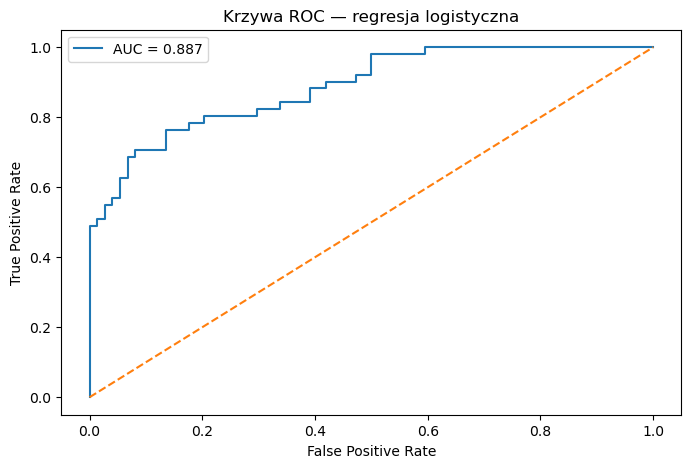

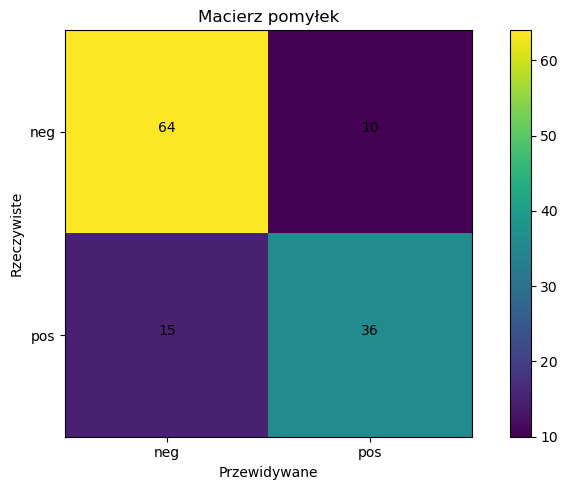

In [14]:

TARGET_CLS = "hypertension"
features = ["age", "sex", "bmi", "systolic_bp", "diastolic_bp", "glucose"]
features = [c for c in features if c in df.columns and c != TARGET_CLS]

X = df[features].copy()
y = df[TARGET_CLS].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

logreg = Pipeline(steps=[
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=1000))
])

logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC AUC:   {auc:.3f}\n")

print("Raport klasyfikacji:")
print(classification_report(y_test, y_pred, digits=3))

# Krzywa ROC
fpr, tpr, thr = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Krzywa ROC — regresja logistyczna")
plt.legend()
plt.show()

# Macierz pomyłek
cm = confusion_matrix(y_test, y_pred)
plt.figure()
plt.imshow(cm, interpolation="nearest")
plt.title("Macierz pomyłek")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["neg", "pos"], rotation=0)
plt.yticks(tick_marks, ["neg", "pos"])
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], "d"),
                 horizontalalignment="center")
plt.ylabel("Rzeczywiste")
plt.xlabel("Przewidywane")
plt.tight_layout()
plt.show()

### 1.4 Regresja: przewidywanie ciśnienia skurczowego (`systolic_bp`)

RMSE: 18.47
R^2 : -0.013


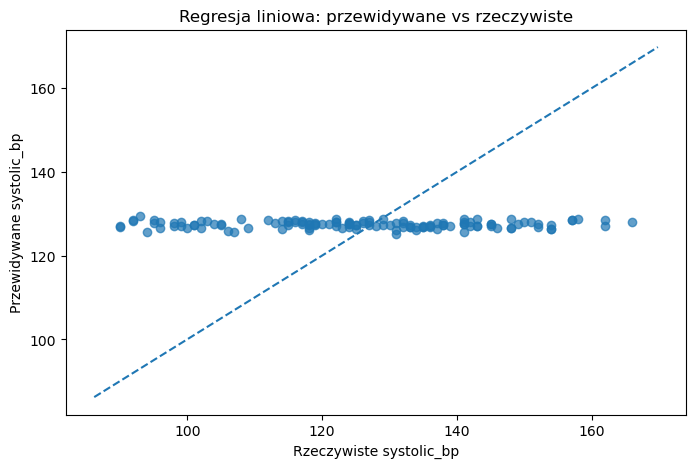

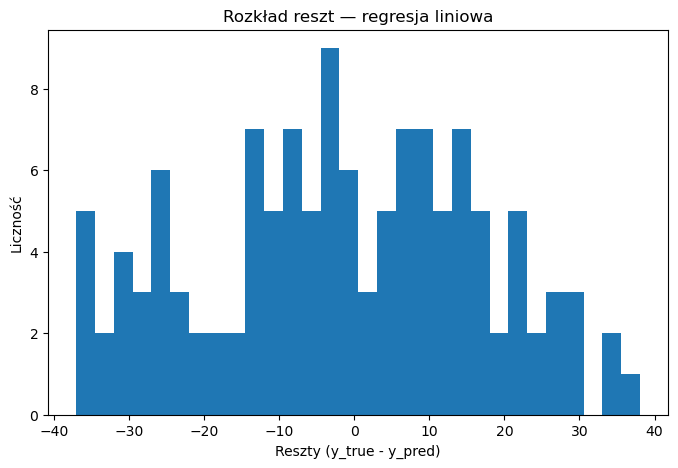

In [15]:

TARGET_REG = "systolic_bp"
reg_features = ["age", "sex", "bmi", "diastolic_bp", "glucose"]
reg_features = [c for c in reg_features if c in df.columns and c != TARGET_REG]

Xr = df[reg_features].copy()
yr = df[TARGET_REG].astype(float)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.25, random_state=42
)

num_features_r = Xr_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features_r = Xr_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

numeric_transformer_r = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer_r = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess_r = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_r, num_features_r),
        ("cat", categorical_transformer_r, cat_features_r),
    ]
)

linreg = Pipeline(steps=[
    ("prep", preprocess_r),
    ("reg", LinearRegression())
])

linreg.fit(Xr_train, yr_train)
yr_pred = linreg.predict(Xr_test)

from math import sqrt
rmse = sqrt(mean_squared_error(yr_test, yr_pred))
r2 = r2_score(yr_test, yr_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R^2 : {r2:.3f}")

plt.figure()
plt.scatter(yr_test, yr_pred, alpha=0.7)
plt.xlabel("Rzeczywiste systolic_bp")
plt.ylabel("Przewidywane systolic_bp")
plt.title("Regresja liniowa: przewidywane vs rzeczywiste")
min_v = min(plt.xlim()[0], plt.ylim()[0])
max_v = max(plt.xlim()[1], plt.ylim()[1])
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.show()

residuals = yr_test - yr_pred
plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Reszty (y_true - y_pred)")
plt.ylabel("Liczność")
plt.title("Rozkład reszt — regresja liniowa")
plt.show()

## 2. Temat: Prosta sieć konwolucyjna (CNN) dla obrazów

Wykorzystamy `sklearn.datasets.load_digits` jako **proxy** danych obrazowych medycznych, aby skupić się na procesie budowy CNN bez konieczności pobierania zewnętrznych zbiorów.


### 2.1 Dane obrazowe: wczytanie i przygotowanie

In [6]:

digits = load_digits()
X_img = digits.images
y_img = digits.target

X_img = X_img.astype("float32") / 16.0
X_img = np.expand_dims(X_img, axis=-1)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_img, y_img, test_size=0.25, random_state=42, stratify=y_img
)

print("Kształt X_train:", X_train_i.shape)
print("Kształt X_test :", X_test_i.shape)

Kształt X_train: (1347, 8, 8, 1)
Kształt X_test : (450, 8, 8, 1)


### 2.2 Architektura CNN i trenowanie

In [7]:

num_classes = 10
model = keras.Sequential([
    layers.Conv2D(16, (3,3), activation="relu", input_shape=X_train_i.shape[1:]),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(
    X_train_i, y_train_i,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    verbose=1
)

Epoch 1/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1266 - loss: 2.2737 - val_accuracy: 0.1148 - val_loss: 2.2344
Epoch 2/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2173 - loss: 2.1763 - val_accuracy: 0.4630 - val_loss: 2.0776
Epoch 3/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5239 - loss: 1.9746 - val_accuracy: 0.7704 - val_loss: 1.7606
Epoch 4/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7298 - loss: 1.6493 - val_accuracy: 0.8185 - val_loss: 1.3282
Epoch 5/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7642 - loss: 1.2279 - val_accuracy: 0.7889 - val_loss: 0.9315
Epoch 6/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7918 - loss: 0.8634 - val_accuracy: 0.8667 - val_loss: 0.6710
Epoch 7/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8902 - loss: 0.6223 - val_accuracy: 0.8741 - val_loss: 0.5373
Epoch 8/8
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9117 - loss: 0.4654 - val_accuracy: 0.8926 - val_loss: 0.4501

### 2.3 Ocena i wizualizacja wyników

Test accuracy: 0.871  |  Test loss: 0.455


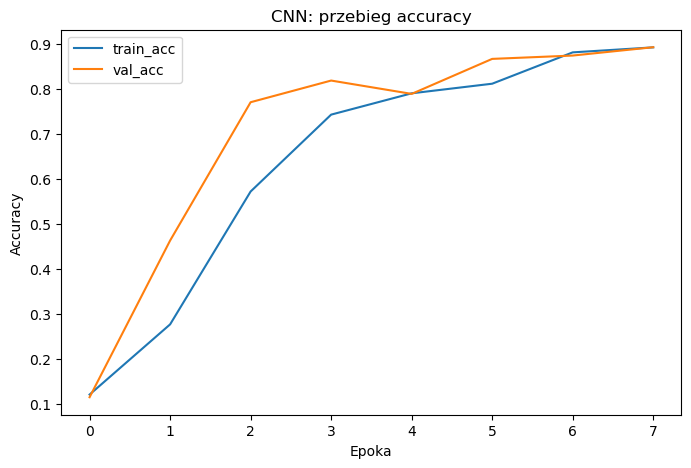

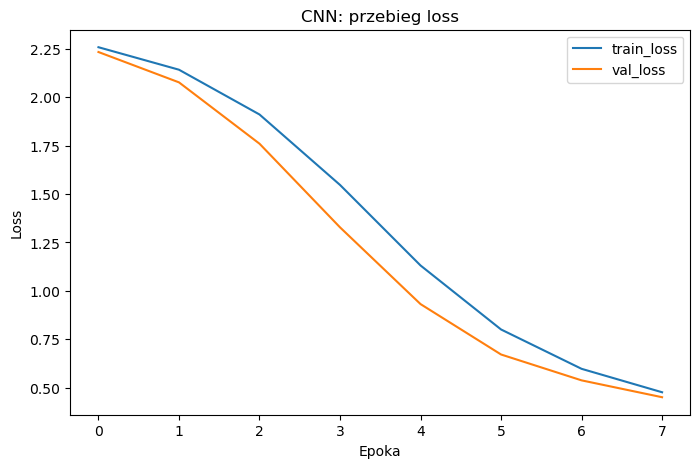

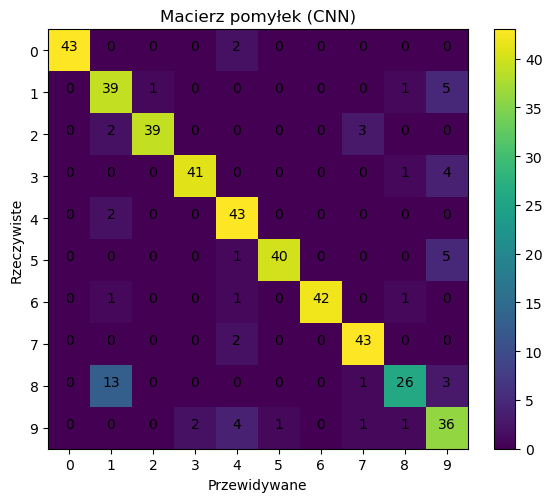

In [8]:

test_loss, test_acc = model.evaluate(X_test_i, y_test_i, verbose=0)
print(f"Test accuracy: {test_acc:.3f}  |  Test loss: {test_loss:.3f}")

plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.xlabel("Epoka")
plt.ylabel("Accuracy")
plt.title("CNN: przebieg accuracy")
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoka")
plt.ylabel("Loss")
plt.title("CNN: przebieg loss")
plt.legend()
plt.show()

from sklearn.metrics import confusion_matrix
y_pred_i = model.predict(X_test_i, verbose=0).argmax(axis=1)
cm_i = confusion_matrix(y_test_i, y_pred_i)

plt.figure(figsize=(6,5))
plt.imshow(cm_i, interpolation="nearest")
plt.title("Macierz pomyłek (CNN)")
plt.colorbar()
ticks = np.arange(num_classes)
plt.xticks(ticks, ticks)
plt.yticks(ticks, ticks)
for i in range(cm_i.shape[0]):
    for j in range(cm_i.shape[1]):
        plt.text(j, i, format(cm_i[i, j], "d"),
                 horizontalalignment="center")
plt.ylabel("Rzeczywiste")
plt.xlabel("Przewidywane")
plt.tight_layout()
plt.show()

## 3. Podsumowanie i zadania własne

- **Część tablicowa:** porównaj różne modele i zestawy cech, dodaj walidację krzyżową.
- **Część obrazowa:** zmień architekturę (liczba filtrów, głębokość), epoki i batch size, zaobserwuj wpływ na jakość.

**Praktyka bezpieczeństwa:** używaj wyłącznie zanonimizowanych danych pacjentów i trzymaj się wytycznych etycznych.
